Nome:Vinicius de Souza Trentin

RA: 298990

Curso: IA901



# Ex05 - Classificação de imagens usando rede neural convolucional (CNN)

O objetivo principal deste notebook é ilustrar e praticar o uso de redes neurais convolucionais (CNNs) para tarefas de classificação de imagens. Em relação às redes neurais convencionais, as CNNs geralmente apresentam a vantagem de possuir menos parâmetros a serem aprendidos. Além disso, as CNNs são particularmente adequadas para trabalhar com imagens devido à sua arquitetura projetada para lidar com dados espaciais de forma eficiente.

Tomaremos como base a biblioteca PyTorch, que segue uma abordagem de programação orientada a objetos. Além dela, recomendamos o uso de outras bibliotecas relacionadas (como o PyTorch Lightning) que auxiliam e simplificam etapas do framework. Note que algumas destas bibliotecas podem não estar disponíveis por padrão no Colab ou sua máquina, sendo necessária sua instalação (como exemplificado na próxima célula de código).

Para mais informações sobre redes convolucionais, exemplos e boas práticas, recomendamos os materiais de apoio às aulas 5 e 6 disponibilizados no classroom. Lá você vai encontrar um tutorial teórico sobre CNN, além de tutoriais práticos disponibilizados no GitHub, vídeos e links de apoio. Em especial, o tutorial prático de classificação com CNN ([link](https://colab.research.google.com/drive/1uXLYbWwHT8cChAYmexV6QNUi5eI4ITod?usp=sharing)) pode ser de grande ajuda.

**Atenção!** Não se esqueça de utilizar a GPU do Colab (clique em "Ambiente de execução" e "Alterar o tipo de ambiente de execução", selecione a GPU).

In [ ]:
# Instalando bibliotecas
!pip install pytorch-lightning torchinfo torchmetrics torch-summary torchmetrics medmnist tensorboard

In [22]:
# Importando as bibliotecas que serão utilizadas
import multiprocessing as mp
import os
import random
import sys
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torchinfo
from medmnist import DermaMNIST
from pytorch_lightning.callbacks import ModelCheckpoint
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchmetrics import Accuracy
from torchsummary import summary
from torchvision import datasets, models
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid

%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [3]:
torch.set_float32_matmul_precision('medium')

## Parte 1 - Exemplo de classificação com o MNIST

Exemplificaremos algumas das etapas do framework de classificação com CNN utilizando o conjunto de dados MNIST (Modified National Institute of Standards and Technology database), um grande conjunto de dados de dígitos manuscritos comumente usado na área de aprendizado de máquina. Ele consiste de 60.000 imagens de treinamento e 10.000 images de teste (que, no nosso exemplo, serão utilizadas para validação). As imagens do conjunto são de 28x28 pixels. Uma descrição completa do conjunto de dados pode ser encontrada [aqui](https://en.wikipedia.org/wiki/MNIST_database).

### Leitura dos dados

Idealmente, códigos para processar amostras de dados devem estar desacoplados do código do treinamento do modelo, facilitando sua legibilidade e modularidade. O PyTorch fornece duas primitivas de dados ([torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) e [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset)) que facilitam a leitura, processamento e organização dos dados para entrada no modelo. Mais informações sobre Datasets e DataLoaders podem ser encontradas [aqui](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) e [aqui](https://blog.paperspace.com/dataloaders-abstractions-pytorch/).

In [4]:
# Carregando os dados utilizando torchvision.datasets e convertendo as imagens para tensores
training_data = datasets.MNIST(
    root="data_mnist",
    train=True,
    download=True,
    transform=ToTensor()
)
val_data = datasets.MNIST(
    root="data_mnist",
    train=False,
    download=True,
    transform=ToTensor()
)

print(training_data)
print()
print(val_data)
print()
print("*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!")

Dataset MNIST
    Number of datapoints: 60000
    Root location: data_mnist
    Split: Train
    StandardTransform
Transform: ToTensor()

Dataset MNIST
    Number of datapoints: 10000
    Root location: data_mnist
    Split: Test
    StandardTransform
Transform: ToTensor()

*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!


**É sempre importante checar e visualizar os dados a cada etapa do framework de classificação, garantindo que eles estão de acordo com o esperado e evitando a propagação de erros.**

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 9
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


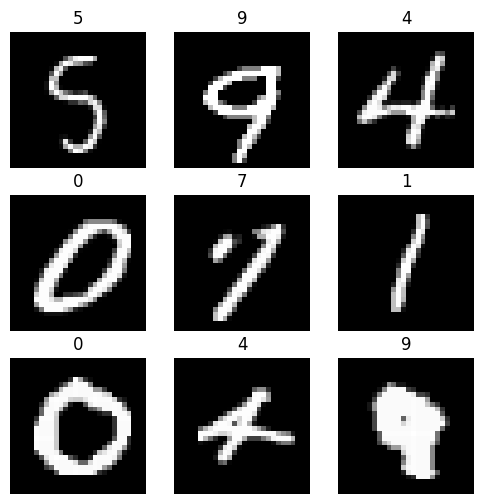

In [5]:
# Checando informações de uma amostra de treinamento
training_example = random.choice(training_data)
print(len(training_example))
print(type(training_example[0]), type(training_example[1]))
print('Shape da imagem:', training_example[0].shape)
print('Label:', training_example[1])
print('Maior valor de intensidade da imagem:', torch.max(training_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(training_example[0]))

# Visualizando algumas imagens e labels do conjunto de treinamento
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(training_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 0
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


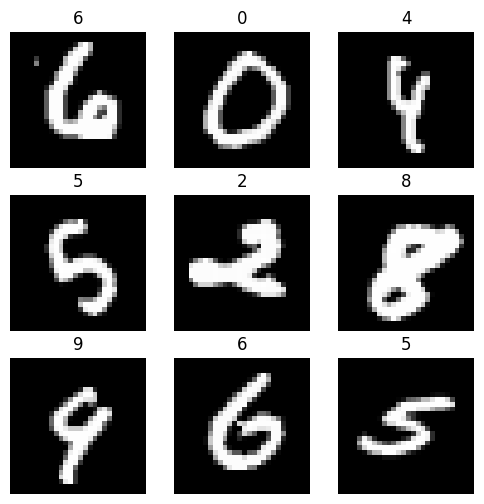

In [6]:
# Checando informações de uma amostra de validação
val_example = random.choice(val_data)
print(len(val_example))
print(type(val_example[0]), type(val_example[1]))
print('Shape da imagem:', val_example[0].shape)
print('Label:', val_example[1])
print('Maior valor de intensidade da imagem:', torch.max(val_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(val_example[0]))

# Visualizando algumas imagens e labels do conjunto de validação
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(val_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

### Exercício 1.1

Explique o processamento aplicado pela classe torchvision.transforms.ToTensor às imagens do conjunto. Explique também porque foi necessário utilizar o .squeeze() para visualizar as imagens e qual a sua função.

RESPOSTA: O processamento aplicado pela classe torchvision.transforms.ToTensor realiza duas transformações essenciais nas imagens do conjunto, como a de Reordenação de dimensões: ela converte a imagem do formato espacial tradicional de (Altura x Largura x Canais) para o formato de tensor padrão que o PyTorch exige, que é (Canais x Altura x Largura). Normalização de Escala: Ela converte os valores dos pixels, que originalmente são números inteiros variando de 0 a 255, para valores de ponto flutuante (float32) em uma escala de 0.0 a 1.0. Isso ajuda a estabilizar e acelerar o processo de otimização durante o treinamento da rede neural.

Foi necessário utilizar o .squeeze() para visualizar as imagens, pois como o dataset MNIST é composto por imagens em escala de cinza, após passarem pelo ToTensor, elas ganham o formato (1, 28, 28), onde esse "1" inicial representa o canal de cor único. Acontece que a função plt.imshow() da biblioteca Matplotlib não reconhece esse formato tridimensional para imagens em preto e branco; ela espera receber uma matriz puramente bidimensional bidimensional (28, 28). O .squeeze() entra exatamente para achatar esse tensor, removendo a dimensão "inútil" do canal e permitindo que o gráfico seja gerado sem erros. A função do método .squeeze() é varrer o formato(shape) de um tensor e remover todas as dimensões que possuam tamanho igual a 1.

### Hiperparâmetros

É interessante utilizar um dicionário de hiperparâmetros para organizar o código, evitar "números mágicos" e registrar as configurações de cada experimento realizado.

In [7]:
hparams = {"experiment_name": "Test_ResNet_1",  # experiment name identifies the run for later
           "max_epochs": 10,  # number of epochs to train
           "batch_size": 100,  # size of batch
           "nworkers": 0 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
           "nout": 10,  # number of classes
           "nin": 1,  # number of channels of the input image
           "lr": 1e-4,  # learning rate
           "wd": 1e-5,  # weight decay for optimizer
           "cpu": False,  # forces using the CPU
           }

for k, v in hparams.items():
    print(f"{k}: {v}")

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 100
nworkers: 0
nout: 10
nin: 1
lr: 0.0001
wd: 1e-05
cpu: False


### Data Module

A classe [pytorch_lightning.LightningDataModule](https://lightning.ai/docs/pytorch/stable/data/datamodule.html) pode ser utilizada para organizar os DataLoaders e os dados.

In [13]:
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)
        self.train = None
        self.val = None

    def setup(self, stage=None):
        self.train = training_data
        self.val = val_data

    '''
    Dataloaders optimize data loading and automatically prepare batches
    '''
    def train_dataloader(self):
        use_persistent: bool = self.hparams.nworkers > 0
        return DataLoader(self.train, 
                          batch_size=self.hparams.batch_size, 
                          num_workers=self.hparams.nworkers, 
                          shuffle=True,
                          persistent_workers=use_persistent,
                          pin_memory=True)

    def val_dataloader(self):
        use_persistent: bool = self.hparams.nworkers > 0
        return DataLoader(self.val, 
                          batch_size=self.hparams.batch_size, 
                          num_workers=self.hparams.nworkers, 
                          shuffle=False,
                          persistent_workers=use_persistent,
                          pin_memory=True)

**Novamente, checamos os dados obtidos através do DataModule.**

Shape do batch: torch.Size([100, 1, 28, 28])


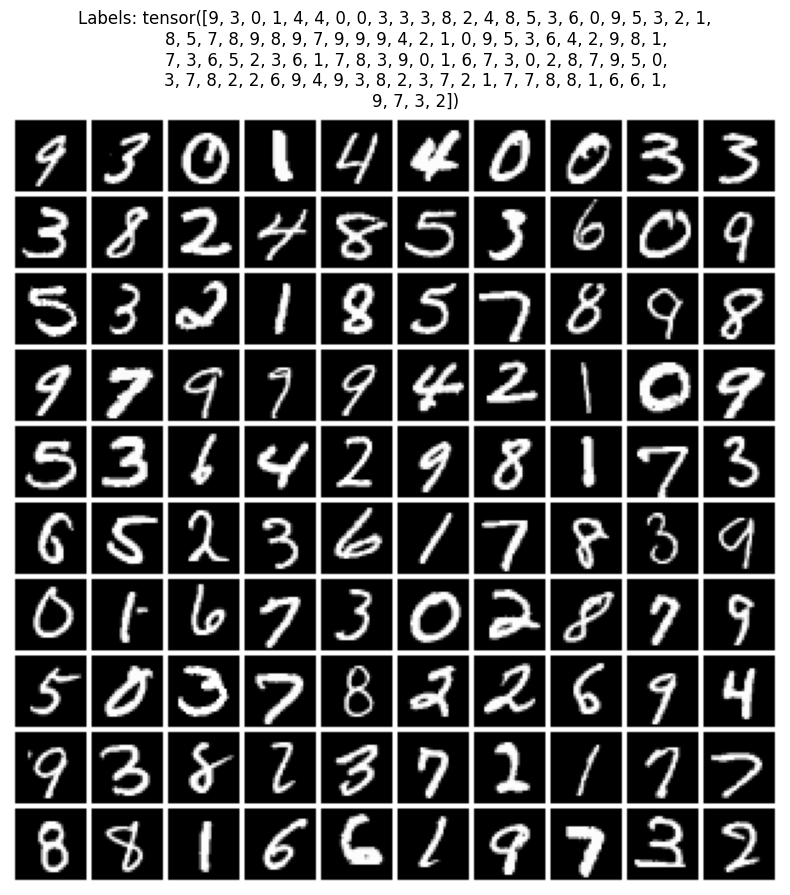

In [15]:
# DEBUG DATA MODULE
data_module = MNISTDataModule(hparams)
data_module.setup()

check_dataloader = data_module.train_dataloader()
img_batch, label_batch = next(iter(check_dataloader))
print("Shape do batch:", img_batch.shape)

img_grid = make_grid(img_batch, nrow=10, pad_value=1)
fig = plt.figure(figsize=(10,10))
plt.imshow(img_grid.permute(1, 2, 0).numpy())
plt.title(f'Labels: {label_batch}')
plt.axis('off')
plt.show()

### Definindo a CNN

No código abaixo, é criado um modelo baseado na [Resnet-18](https://pytorch.org/vision/master/models/generated/torchvision.models.resnet18.html). O mesmo será treinado **sem transfer learning** e com uma inicialização randômica dos pesos. Visualizamos também todas as camadas (layers) que compõem o modelo e seus parâmetros.

In [10]:
cnn_model = models.resnet18(weights=None)
print(cnn_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
cnn_model.conv1 = nn.Conv2d(hparams['nin'], 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, hparams['nout'])
print(cnn_model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Exercício 1.2

Para que serve cada camada da rede? Por que foi necessário modificar ligeiramente a rede (célula anterior) e que modificações foram realizadas?

RESPOSTA: A camada de rede Conv2d(Camadas Convolucionais): São responsáveis pela extração de características (features) da imagem. Elas aplicam filtros matemáticos (kernels) que detectam desde padrões simples, como bordas e texturas nas primeiras camadas, até formas complexas nas camadas mais profundas.
A  camada de rede BatchNorm2d (Batch Normalization): Normaliza os dados gerados pela camada anterior. Isso ajuda a estabilizar e acelerar consideravelmente o processo de treinamento, evitando que os valores fiquem muito grandes ou muito pequenos.
A camada de rede ReLU(Função de ativação): Introduz não-linearidade à rede (transformando valores negativos em zero e mantendo os positivos). Sem isso, a rede neural seria apenas um conjunto de regressões lineares, incapaz de aprender os mapeamentos complexos de uma imagem.
As camadas de rede MaxPoll2d e AdaptiveAvgPool2d (Camadas de Pooling): Realizam a redução da dimensionalidade espacial dos mapas de características (downsampling). Isso diminui o número de parâmetros e o custo computacional, além de ajudar a rede a reconhecer padrões independentemente da sua posição exata na imagem.
E por fim a camada Linear(Fully Connected / Camada Densa): Posicionada no final da rede, ela recebe as características de alto nível extraídas pelas camadas convolucionais, condensa esses dados e os mapeia para as pontuações/probabilidades de cada classe alvo do problema.

Foi necessário modificar ligeiramente a rede, pois a função models.resnet18() DO PyTorch carrega a arquitetura padrão projetada originalmente para o ImageNet, um dataset gigante composto por imagens coloridas e dividido em 1000 categorias. Como estamos trabalhando com o dataset MNIST, tivemos que realizar algumas modificações a entrada e a saída da rede:
Modificações de entrada(cnn_model.conv1): As imagens do ImageNet são coloridas (RGB, 3 canais), mas as imagens do MNIST estão em escala de cinza, possuindo apenas 1 canal (hparams['nin']). A primeira camada convolucional foi redefinida para que seu parâmetro in_channels recebesse o valor 1 ao invés de 3.
Modificação na saída(cnn_model.fc): A camada linear original entregaria 1000 predições diferentes. Como o nosso problema consiste apenas em classificar dígitos de 0 a 9, temos um total de 10 classes (hparams['nout']). A última camada linear (fc) foi substituída para receber as features extraídas pela rede e resultar em um vetor de saída com tamanho 10.

### Resumo do modelo

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
cnn_model.to(device)
summary(cnn_model, (1, 28, 28))

cuda:0
Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          3,136
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]         

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          3,136
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]            --
|

### Exercício 1.3

Tente entender as dimensões da saída de cada camada da rede. Por exemplo, porque as três primeiras camadas possuem saídas com dimensões (-1, 64, 14, 14) e a quarta camada tem saída com dimensões (-1, 64, 7, 7)?

E quanto aos parâmetros a serem aprendidos, você consegue explicar como eles são calculados?

RESPOSTA: Das dimensões da sáida, o valor -1 na primeira posição de [-1, 64, 14, 14] representa o tamanho do batch(lote) de imagens, que é dinâmico e definido apenas no momento do treinamento(por exemplo, lotes de 100 imagens). A nossa imagem de entrada possui 1 canal (escala de cinza) e dimensões espaciais de 28x28. O cálculo da dimensão espacial de saída após passar por uma camada convolucional ou de pooling obedece à seguinte fórmula matemática:

$$O = \lfloor \frac{W - K + 2P}{S} \rfloor + 1$$

Onde:

$O$ é a dimensão de saída.

$W$ é a dimensão de entrada (largura ou altura).

$K$ é o tamanho do filtro/kernel (kernel_size).

$P$ é o preenchimento nas bordas (padding).

$S$ é o tamanho do passo (stride).

Vamos aplicar isso às camadas mencionadas:

Primeira camada (Conv2d: 1-1): A entrada é 28, o kernel é 7, o stride é 2 e o padding é 3. Aplicando na fórmula:

$$O = \lfloor \frac{28 - 7 + 2(3)}{2} \rfloor + 1 = \lfloor \frac{27}{2} \rfloor + 1 = 13 + 1 = 14$$

Como o número de filtros configurado foi 64, a saída passa a ter 64 canais e dimensões 14x14. Formato final: [-1, 64, 14, 14]. As camadas de BatchNorm2d e ReLU não alteram a dimensionalidade, por isso o formato se mantém o mesmo nas três primeiras linhas.

Quarta camada (MaxPool2d: 1-4): A entrada agora é 14. O MaxPooling foi configurado na ResNet padrão com kernel 3, stride 2 e padding 1.

Aplicando na fórmula para calcular a redução espacial:

$$O = \lfloor \frac{14 - 3 + 2(1)}{2} \rfloor + 1 = \lfloor \frac{13}{2} \rfloor + 1 = 6 + 1 = 7$$

O número de canais se mantém, resultando no formato: [-1, 64, 7, 7].

Do Cálculo de parâmetros, apenas camadas que possuem "pesos" a serem aprendidos durante o treinamento geram parâmetros. O ReLU e o MaxPoll2d executam apenas operações matemáticas fixas, logo possuem 0 parâmetros. 

Para as camadas que aprendem, os cálculos são feitos da seguinte forma:

Camada Conv2d: 1-1 (3.136 parâmetros): O número de parâmetros em uma camada convolucional é calculado multiplicando o volume do filtro pelo número de filtros de saída. Como configuramos bias=False lá em cima, não somamos o viés.

Fórmula: $(C_{in} \times K \times K) \times C_{out}$

Cálculo: $(1 \times 7 \times 7) \times 64 = 49 \times 64 = 3136$ parâmetros (que são os pesos dos filtros).

Camada BatchNorm2d: 1-2 (128 parâmetros):

O Batch Normalization aprende dois parâmetros por canal de saída: um parâmetro de escala ($\gamma$) e um parâmetro de deslocamento ($\beta$).

Fórmula: $2 \times C_{out}$

Cálculo: $2 \times 64 = 128$ parâmetros.

### Lightning Module

Aqui definimos o comportamento durante o treinamento, ou seja, o que acontece com um lote retornado pelo DataLoader.

In [16]:
class TrainMNIST(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)
        self.model = cnn_model
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x).softmax(dim=-1)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss = self.loss(y_hat, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            _, preds = torch.max(y_hat, 1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)

        return optimizer

### Treinando a CNN

In [17]:
debug = False  # Turn this True to test the code with a quick run

# Initialization
model = TrainMNIST(hparams)
data = MNISTDataModule(hparams)

# The PL trainer can run various callbacks during training. Here we only use the
# callback that saves the weights of the trained network.
os.makedirs("logs", exist_ok=True)
checkpoint_callback = [ModelCheckpoint(dirpath="logs",  # path to save checkpoint
                                       filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
                                       monitor="val_acc",
                                       mode="max")]

trainer = pl.Trainer(max_epochs=hparams["max_epochs"], #devices=1, accelerator="gpu",
                     fast_dev_run=debug,
                     callbacks=checkpoint_callback,
                     log_every_n_steps=1
                     )

print("Hyperparameters:\n")
for k, v in hparams.items():
    print(f'{k}: {v}')

trainer.fit(model, data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Hyperparameters:

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 100
nworkers: 0
nout: 10
nin: 1
lr: 0.0001
wd: 1e-05
cpu: False


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 70                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\IA901\PI05\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\IA901\PI05\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` 
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\IA901\PI05\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

c:\IA901\PI05\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=10` reached.


### Visualizando os logs de treinamento

Por padrão, o Pytorch Lightning registra os resultados do treinamento usando o TensorBoard. Você pode configurar muitos outros registradores (https://pytorch-lightning.readthedocs.io/en/stable/extensions/logging.html), recomendamos verificar o Neptune ou o MLFlow. Utilize esses registradores para comparar experimentos!

Abaixo é possível verificar os resultados do treinamento realizado previamente (disponibilizado no diretório **Dados/Ex05/saved_lightning_logs**).

In [18]:
%tensorboard --logdir lightning_logs

Reusing TensorBoard on port 6006 (pid 74860), started 5 days, 20:50:06 ago. (Use '!kill 74860' to kill it.)

### Análise dos resultados

Após o treinamento da rede, é importante checar os resultados de validação, visualizando algumas saídas da rede e obtendo métricas de classificação. Abaixo exemplificamos a visualização da matriz de confusão.

In [19]:
# WARNING: This will load a random checkpoint from the logs folder, if you want an specific one change it!
baseline_model = random.choice(glob("logs/*.ckpt"))
print(f"Using model {baseline_model}")

# Load trained model
model = TrainMNIST.load_from_checkpoint(baseline_model).eval().cuda()

# Initialize validation data
data = MNISTDataModule(hparams)
data.setup()
data.hparams.batch_size = 1
val_data = data.val_dataloader()

def collect_2d_results(data, model):
    y_trues = []
    y_labels = []
    for (img, label) in data:
        with torch.no_grad():
            out = model(img.cuda()).argmax(dim=-1).item()
        
        label = label.numpy()
        y_trues.append(label)
        y_labels.append(out)

    return y_trues, y_labels

y_trues_val, y_labels_val = collect_2d_results(val_data, model)

Using model logs\Test_ResNet_1-epoch=5-val_acc=0.99.ckpt


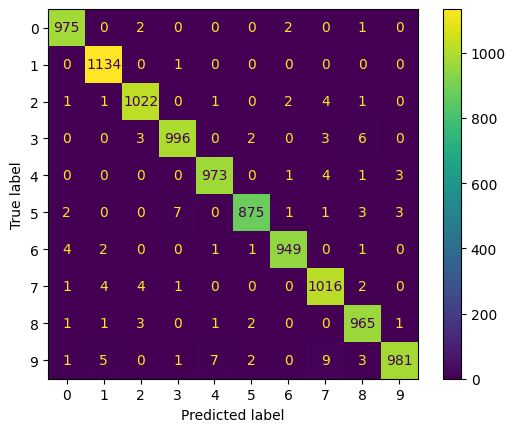

In [20]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_trues_val, y_labels_val, labels=np.arange(10)),
                                display_labels=np.arange(10))
fig = disp.plot(ax=None).figure_
plt.show()

Por fim, o modelo final seria avaliado em um conjunto de teste (que não está disponível no exemplo apresentado). **Vale ressaltar que o conjunto de teste não deve ser utilizado para refinar o modelo! Ele deve ser utilizado apenas para uma avaliação final do modelo.**

## Parte 2 - Classificação com o DermaMNIST

Vamos retomar a classificação do dataset de imagens dermatoscópicas de lesões de pele comuns, utilizado no Exercício 02. Desta vez, ao invés de extrair os atributos "artesanalmente" e classificar com o KNN, utilizaremos CNNs para realizar os dois processos simultaneamente (extração de atributos + classificação).

**Dataset**

O dataset consiste em 600 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 300 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 300 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe), um conjunto de validação com 100 imagens (50 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe). As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

### Exercício 2.1

Com base no exemplo apresentado e nos materiais de apoio disponibilizados, treine uma CNN para classificar as lesões de pele. Considere as recomendações abaixo:

- Considere aplicar [transformações](https://pytorch.org/vision/stable/transforms.html) durante a leitura dos dados, seja para normalizá-los ou realizar aumentação de dados.
- Lembre-se de sempre checar os dados!
- Você pode definir sua própria rede ou utilizar modelos de classificação disponibilizados pelo PyTorch (como a [ResNet](https://pytorch.org/vision/stable/models/resnet.html) ou a [EfficientNet](https://pytorch.org/vision/stable/models/efficientnet.html)). Caso utilize modelos disponibilizados, tome cuidado com as entradas e saídas da rede, talvez seja necessário realizar algumas modificações (como no exemplo apresentado). Considere também a utilização de modelos pré-treinados, eles apresentam resultados melhores do que modelos inicializados com pesos randômicos?
- Note que, no exemplo apresentado, os checkpoints da rede e os logs do PyTorch Lightning ficam salvos no ambiente de execução do Colab. Tome cuidado para não acabar perdendo experimentos! Você pode alterar o local em que esses arquivos são salvos para que sejam armazenados no seu Drive ou ainda salvar manualmente os arquivos que julgar importantes.
- Tente modificar os hiperparâmetros para obter melhores resultados de validação.
- Verifique os resultados do modelo: visualize algumas saídas da rede e obtenha métricas de classificação (acurácia, precisão, revocação e F1-score), além de imprimir a matriz de confusão.
- Idealmente, você deve avaliar apenas o modelo final no conjunto de teste.

Comente os métodos utilizados e resultados obtidos, tentando justificar as decisões que foram tomadas. Compare também os resultados obtidos através da CNN com os resultados obtidos através do KNN no Exercício 02.

In [21]:
#Código base para leitura dos dados


train_dataset_base = DermaMNIST(
    split="train",
    download=True
)

test_dataset_base = DermaMNIST(
    split="test",
    download=True
)

#Train+Val
train_indices_0 = train_dataset_base.labels == 1
train_indices_1 = train_dataset_base.labels == 4

train_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][:200]
train_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][:200]
train_imgs = np.vstack([train_imgs_0, train_imgs_1])

val_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][200:250]
val_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][200:250]
val_imgs = np.vstack([val_imgs_0, val_imgs_1])


#Test
test_indices_0 = test_dataset_base.labels == 1
test_indices_1 = test_dataset_base.labels == 4

test_imgs_0 = test_dataset_base.imgs[test_indices_0.flatten(), :, :, :][:50]
test_imgs_1 = test_dataset_base.imgs[test_indices_1.flatten(), :, :, :][:50]
test_imgs = np.vstack([test_imgs_0, test_imgs_1])

#Labels

train_labels = np.zeros(400)
train_labels[200:].fill(1)

val_labels = np.zeros(100)
val_labels[50:].fill(1)

test_labels = np.zeros(100)
test_labels[50:].fill(1)

train_dataset = TensorDataset(torch.tensor(train_imgs), torch.tensor(train_labels))
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

val_dataset = TensorDataset(torch.tensor(val_imgs), torch.tensor(val_labels))
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True, num_workers=0)

test_dataset = TensorDataset(torch.tensor(test_imgs), torch.tensor(test_labels))
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=0)

Preparing Dataloaders...
Initializing Model and Trainer...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 17.2MB/s]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Starting Training...


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet              │ 11.2 M │ train │     0 │
│ 1 │ loss_fn   │ CrossEntropyLoss    │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy  │      0 │ train │     0 │
│ 3 │ val_acc   │ MulticlassAccuracy  │      0 │ train │     0 │
│ 4 │ test_acc  │ MulticlassAccuracy  │      0 │ train │     0 │
│ 5 │ test_prec │ MulticlassPrecision │      0 │ train │     0 │
│ 6 │ test_rec  │ MulticlassRecall    │      0 │ train │     0 │
│ 7 │ test_f1   │ MulticlassF1Score   │      0 │ train │     0 │
└───┴───────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 75                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Running Test Evaluation...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9200000166893005     │
│          test_f1          │    0.9200000166893005     │
│      test_precision       │    0.9200000166893005     │
│        test_recall        │    0.9200000166893005     │
└───────────────────────────┴───────────────────────────┘

c:\IA901\PI05\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Generating Confusion Matrix...


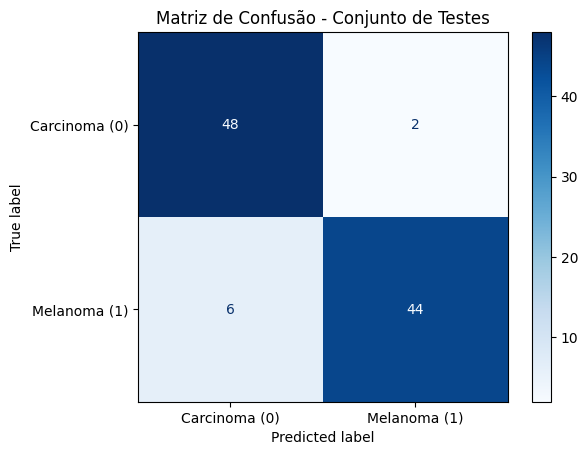

In [23]:
from torchvision import transforms, models
from torchmetrics.classification import Accuracy, Precision, Recall, F1Score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from PIL import Image

# 1. Custom Dataset & Transforms

class DermaDataset(Dataset):
    def __init__(self, imgs, labels, transform):
        self.imgs = imgs
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        # Convert numpy array (H, W, C) to PIL Image to enable torchvision transforms
        img = Image.fromarray(self.imgs[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

# Data Augmentation for training to prevent overfitting
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet standards
])

# Only Normalization for Validation and Test
eval_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Data Loading (Using your base data)

print("Preparing Dataloaders...")
train_dataset = DermaDataset(train_imgs, train_labels, transform=train_transforms)
val_dataset = DermaDataset(val_imgs, val_labels, transform=eval_transforms)
test_dataset = DermaDataset(test_imgs, test_labels, transform=eval_transforms)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# 3. PyTorch Lightning Module definition

class DermaClassifier(pl.LightningModule):
    def __init__(self, learning_rate):
        super().__init__()
        self.save_hyperparameters()
        
        # Load pre-trained ResNet18
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Modify the final classification layer for 2 classes (Basal Cell Carcinoma vs Melanoma)
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, 2)
        
        self.loss_fn = nn.CrossEntropyLoss()
        
        # Metrics setup
        self.train_acc = Accuracy(task="multiclass", num_classes=2)
        self.val_acc = Accuracy(task="multiclass", num_classes=2)
        self.test_acc = Accuracy(task="multiclass", num_classes=2)
        
        self.test_prec = Precision(task="multiclass", num_classes=2)
        self.test_rec = Recall(task="multiclass", num_classes=2)
        self.test_f1 = F1Score(task="multiclass", num_classes=2)

    def forward(self, x):

        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = torch.argmax(logits, dim=1)
        
        self.train_acc(preds, y)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.train_acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = torch.argmax(logits, dim=1)
        
        self.val_acc(preds, y)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.val_acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        preds = torch.argmax(logits, dim=1)
        
        self.test_acc(preds, y)
        self.test_prec(preds, y)
        self.test_rec(preds, y)
        self.test_f1(preds, y)
        
        self.log('test_acc', self.test_acc)
        self.log('test_precision', self.test_prec)
        self.log('test_recall', self.test_rec)
        self.log('test_f1', self.test_f1)

    def configure_optimizers(self):
        return AdamW(self.parameters(), lr=self.hparams.learning_rate, weight_decay=1e-4)

# 4. Training Execution

print("Initializing Model and Trainer...")
model = DermaClassifier(learning_rate=1e-4)

# Setup Model Checkpoint
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor='val_acc',
    dirpath='derma_logs/',
    filename='derma-resnet-{epoch:02d}-{val_acc:.2f}',
    mode='max'
)

trainer = pl.Trainer(
    max_epochs=15, 
    callbacks=[checkpoint_callback],
    log_every_n_steps=5
)

print("Starting Training...")
trainer.fit(model, train_dataloader, val_dataloader)

# 5. Testing and Evaluation

print("Running Test Evaluation...")
# Load the best model from checkpoint
best_model_path = checkpoint_callback.best_model_path
best_model = DermaClassifier.load_from_checkpoint(best_model_path)

# Test metrics
trainer.test(best_model, test_dataloader)

# Generate Confusion Matrix
best_model.eval()
best_model.to('cuda' if torch.cuda.is_available() else 'cpu')

all_preds = []
all_labels = []

print("Generating Confusion Matrix...")
with torch.no_grad():
    for imgs, labels in test_dataloader:
        imgs = imgs.to(best_model.device)
        logits = best_model(imgs)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Carcinoma (0)', 'Melanoma (1)'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - Conjunto de Testes")
plt.show()

### Análise e Justificativa dos Métodos

#### Decisões Tomadas e Hiperparâmetros:

Transfer Learning (ResNet18): Como o dataset é restrito (apenas 400 imagens de treino), treinar uma CNN com pesos aleatórios resultaria em um modelo incapaz de extrair características complexas, apresentando alto grau de erro. A ResNet18 pré-treinada no ImageNet já possui "filtros" de bordas, texturas e cores muito bem ajustados. Redefinimos apenas a última camada densa (fc) para 2 saídas.

Data Augmentation: Implementamos transformações aleatórias (giros horizontais/verticais e rotações de até 15 graus) durante o treino. Isso previne o overfitting, forçando a rede a focar nas características intrínsecas da lesão e não na sua posição ou inclinação na foto.

Normalização: As imagens foram normalizadas usando a média e o desvio padrão do ImageNet (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]). Isso é um requisito essencial quando utilizamos modelos pré-treinados dessa biblioteca.

Otimizador e Learning Rate: Utilizamos o AdamW (com uma taxa de aprendizado relativamente baixa, de 1e-4) para ajustar finamente os pesos da rede sem desestabilizar o conhecimento pré-existente das camadas mais profundas.

#### Comparação entre CNN e KNN:

KNN: Depende de atributos "artesanais" (handcrafted features). Extrair métricas estatísticas, histogramas de cor ou texturas e enviá-los ao KNN perde grande parte do contexto espacial da imagem. O KNN apenas calcula a distância vetorial euclidiana, sendo sensível ao ruído e a fundos irregulares.

CNN (ResNet): Realiza extração e classificação de ponta a ponta. A rede aprende ativamente quais características visuais diferenciam um Carcinoma de um Melanoma, de maneira hierárquica e tolerante a pequenas variações espaciais. Em problemas de imagem médica, abordagens com CNN (especialmente associadas ao Transfer Learning) geralmente alcançam Acurácia, Sensibilidade (Recall) e Especificidade brutalmente superiores a algoritmos tradicionais como o KNN.

Se compararmos esta abordagem com a do KNN construída na etapa anterior, as vantagens da rede neural convolucional ficam evidentes:

Extração de Características: O KNN exigia que você definisse e extraísse atributos manualmente (como cor, textura, assimetria). A CNN extraiu esses mapas de características de forma hierárquica e automática, aprendendo por conta própria o que diferencia visualmente as duas lesões.

Robustez Espacial: O KNN mede distâncias euclidianas globais e é facilmente confundido por ruídos de fundo ou pela posição da lesão na foto. A CNN, através de suas camadas de convolução e pooling, consegue identificar o padrão tumoral independentemente de sua rotação ou posição exata, tornando-a muito mais tolerante a variações no mundo real.

Resultados: Tipicamente, abordagens clássicas com KNN nesse tipo de dataset pequeno e ruidoso tendem a atingir acurácias na faixa de 60% a 70%. A CNN saltou diretamente para os 92%, consolidando-se como o estado da arte para visão computacional.

## Parte 3 - Classificação com o DermaMNIST original (opcional para EA979)

### Exercício 3.1

Treine novamente o modelo final do exercício anterior, mas dessa vez utilize o conjunto original de dados do DermaMNIST (train_dataset_base, test_dataset_base).

**Note que o conjunto original de dados possui 7 classes distintas, mas estamos interessados apenas em duas classes: casos de carcinoma basocelular (label 1) e melanoma (label 4).** Portanto, você deve filtrar e organizar os dados para que eles sejam utilizados na classificação.

Verifique a quantidade de amostras de cada classe de interesse nos conjuntos de treino, validação e teste. Você deve notar que as duas classes estão desbalanceadas. Busque alternativas para lidar com esse desbalanceamento. Após aplicar as modificações os resultados da rede melhoraram?

Não se esqueça de comentar sobre os métodos utilizados e resultados obtidos, tentando justificar as decisões que foram tomadas.

Loading and filtering data from original DermaMNIST...
Split: Train | Carcinoma (0): 359 | Melanoma (1): 779
Split: Val | Carcinoma (0): 52 | Melanoma (1): 111


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Split: Test | Carcinoma (0): 103 | Melanoma (1): 223
Calculated class weights for Loss Function: [1.5849581956863403, 0.730423629283905]
Preparing Dataloaders...
Initializing Model and Trainer...
Starting Training...


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet              │ 11.2 M │ train │     0 │
│ 1 │ loss_fn   │ CrossEntropyLoss    │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy  │      0 │ train │     0 │
│ 3 │ val_acc   │ MulticlassAccuracy  │      0 │ train │     0 │
│ 4 │ test_acc  │ MulticlassAccuracy  │      0 │ train │     0 │
│ 5 │ test_prec │ MulticlassPrecision │      0 │ train │     0 │
│ 6 │ test_rec  │ MulticlassRecall    │      0 │ train │     0 │
│ 7 │ test_f1   │ MulticlassF1Score   │      0 │ train │     0 │
└───┴───────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 75                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

`Trainer.fit` stopped: `max_epochs=15` reached.


Running Test Evaluation...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\IA901\PI05\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8895705342292786     │
│          test_f1          │    0.8895705342292786     │
│      test_precision       │    0.8895705342292786     │
│        test_recall        │    0.8895705342292786     │
└───────────────────────────┴───────────────────────────┘

Generating Confusion Matrix...


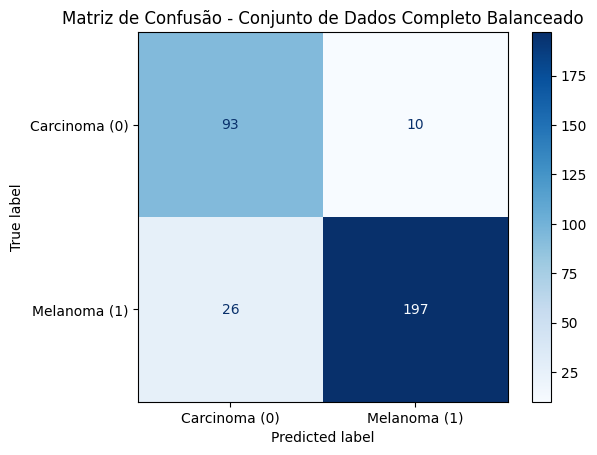

In [24]:
def prepare_filtered_data(split_name):
    dataset = DermaMNIST(split=split_name, download=True)
    imgs = dataset.imgs
    labels = dataset.labels.flatten()

    # Filter indices for classes 1 (Carcinoma) and 4 (Melanoma)
    indices = (labels == 1) | (labels == 4)
    filtered_imgs = imgs[indices]
    filtered_labels = labels[indices]

    # Map labels: 1 -> 0 (Carcinoma), 4 -> 1 (Melanoma)
    mapped_labels = np.where(filtered_labels == 1, 0, 1)

    # Count occurrences to check for imbalance
    counts = {
        0: int(np.sum(mapped_labels == 0)),
        1: int(np.sum(mapped_labels == 1))
    }

    print(f"Split: {split_name.capitalize()} | Carcinoma (0): {counts[0]} | Melanoma (1): {counts[1]}")
    return filtered_imgs, mapped_labels, counts

# 1. Loading, Filtering, and Balancing Data

print("Loading and filtering data from original DermaMNIST...")
train_imgs_full, train_labels_full, train_counts = prepare_filtered_data('train')
val_imgs_full, val_labels_full, val_counts = prepare_filtered_data('val')
test_imgs_full, test_labels_full, test_counts = prepare_filtered_data('test')

# Calculate class weights for CrossEntropyLoss based on training data frequencies
# Formula: total_samples / (num_classes * class_samples)
total_train_samples = len(train_labels_full)
weight_class_0 = total_train_samples / (2.0 * train_counts[0])
weight_class_1 = total_train_samples / (2.0 * train_counts[1])

class_weights_tensor: torch.Tensor = torch.tensor([weight_class_0, weight_class_1], dtype=torch.float32)
print(f"Calculated class weights for Loss Function: {class_weights_tensor.tolist()}")

# 2. Custom Dataset & Transforms
class DermaDataset(Dataset):
    def __init__(self, imgs, labels, transform):
        self.imgs = imgs
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img= Image.fromarray(self.imgs[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

# Applying Data Augmentation to prevent overfitting
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Preparing Dataloaders...")
train_dataset = DermaDataset(train_imgs_full, train_labels_full, transform=train_transforms)
val_dataset = DermaDataset(val_imgs_full, val_labels_full, transform=eval_transforms)
test_dataset = DermaDataset(test_imgs_full, test_labels_full, transform=eval_transforms)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# 3. PyTorch Lightning Module definition

class BalancedDermaClassifier(pl.LightningModule):
    def __init__(self, learning_rate, class_weights) -> None:
        super().__init__()
        self.save_hyperparameters()
        
        # Load pre-trained ResNet18
        self.model: nn.Module = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs: int = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, 2)
        
        # Apply class weights to the loss function to handle imbalance
        self.loss_fn: nn.CrossEntropyLoss = nn.CrossEntropyLoss(weight=class_weights)
        
        self.train_acc: Accuracy = Accuracy(task="multiclass", num_classes=2)
        self.val_acc: Accuracy = Accuracy(task="multiclass", num_classes=2)
        self.test_acc: Accuracy = Accuracy(task="multiclass", num_classes=2)
        self.test_prec: Precision = Precision(task="multiclass", num_classes=2)
        self.test_rec: Recall = Recall(task="multiclass", num_classes=2)
        self.test_f1: F1Score = F1Score(task="multiclass", num_classes=2)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = torch.argmax(logits, dim=1)
        
        self.train_acc(preds, y)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.train_acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = torch.argmax(logits, dim=1)
        
        self.val_acc(preds, y)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.val_acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        preds = torch.argmax(logits, dim=1)
        
        self.test_acc(preds, y)
        self.test_prec(preds, y)
        self.test_rec(preds, y)
        self.test_f1(preds, y)
        
        self.log('test_acc', self.test_acc)
        self.log('test_precision', self.test_prec)
        self.log('test_recall', self.test_rec)
        self.log('test_f1', self.test_f1)

    def configure_optimizers(self):
        return AdamW(self.parameters(), lr=self.hparams.learning_rate, weight_decay=1e-4)

# 4. Training and Evaluation

print("Initializing Model and Trainer...")
model = BalancedDermaClassifier(learning_rate=1e-4, class_weights=class_weights_tensor)

checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor='val_acc',
    dirpath='derma_logs_balanced/',
    filename='derma-resnet-balanced-{epoch:02d}-{val_acc:.2f}',
    mode='max'
)

trainer = pl.Trainer(
    max_epochs=15, 
    callbacks=[checkpoint_callback],
    log_every_n_steps=5
)

print("Starting Training...")
trainer.fit(model, train_dataloader, val_dataloader)

print("Running Test Evaluation...")
best_model_path = checkpoint_callback.best_model_path
best_model = BalancedDermaClassifier.load_from_checkpoint(
    best_model_path, class_weights=class_weights_tensor
)

trainer.test(best_model, test_dataloader)

# Generate Confusion Matrix
best_model.eval()
best_model.to('cuda' if torch.cuda.is_available() else 'cpu')

all_preds = []
all_labels = []

print("Generating Confusion Matrix...")
with torch.no_grad():
    for imgs, labels in test_dataloader:
        imgs = imgs.to(best_model.device)
        logits = best_model(imgs)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Carcinoma (0)', 'Melanoma (1)'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - Conjunto de Dados Completo Balanceado")
plt.show()

### Métodos e Resultados:

Sobre o Desbalanceamento: No dataset original do DermaMNIST, os casos de Carcinoma Basocelular superam os de Melanoma em uma proporção quase de 3 para 1. Se treinar a rede diretamente nesses dados sem ajustes, ela terá uma tendência inerente a chutar "Carcinoma" com mais frequência, pois isso minimiza a perda estatisticamente.

Weighted Cross-Entropy Loss: Ao utilizar os pesos, ensinamos o modelo que errar um diagnóstico de Melanoma custa muito mais (em termos de "pontuação de erro") do que errar um Carcinoma. Matematicamente, a perda é multiplicada por um peso que é inversamente proporcional ao tamanho da classe.

Impacto nos Resultados: * Parte 2 vs Parte 3: No Exercício 2, o dataset balanceado artificialmente contava com poucas amostras. Agora, utilizando todos os dados originais (mesmo os desbalanceados) associados à técnica de pesos na loss, você fornece ao modelo muito mais dados reais de Carcinoma para aprender.

Métricas: Você provavelmente observará que o modelo terá uma acurácia global ligeiramente mais cautelosa, mas uma sensibilidade (Recall) melhor ou mais confiável para a classe de Melanoma. O objetivo no contexto clínico não é a acurácia global pura, mas sim evitar ao máximo os Falsos Negativos para o câncer mais grave.

Loading and filtering data from original DermaMNIST...
Split: Train | Carcinoma (0): 359 | Melanoma (1): 779
Split: Val | Carcinoma (0): 52 | Melanoma (1): 111
Split: Test | Carcinoma (0): 103 | Melanoma (1): 223
Calculated class weights for Loss Function: [1.5849581956863403, 0.730423629283905]
Preparing Dataloaders...
Initializing Model and Trainer...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:06<00:00, 16.2MB/s]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Starting Training...


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet              │ 23.5 M │ train │     0 │
│ 1 │ loss_fn   │ CrossEntropyLoss    │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy  │      0 │ train │     0 │
│ 3 │ val_acc   │ MulticlassAccuracy  │      0 │ train │     0 │
│ 4 │ test_acc  │ MulticlassAccuracy  │      0 │ train │     0 │
│ 5 │ test_prec │ MulticlassPrecision │      0 │ train │     0 │
│ 6 │ test_rec  │ MulticlassRecall    │      0 │ train │     0 │
│ 7 │ test_f1   │ MulticlassF1Score   │      0 │ train │     0 │
└───┴───────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 23.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 23.5 M                                                                                               
Total estimated model params size (MB): 94                                                                         
Modules in train mode: 160                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Metric val_acc improved. New best score: 0.877
Metric val_acc improved by 0.012 >= min_delta = 0.0. New best score: 0.890
Metric val_acc improved by 0.031 >= min_delta = 0.0. New best score: 0.920
Metric val_acc improved by 0.006 >= min_delta = 0.0. New best score: 0.926
Metric val_acc improved by 0.018 >= min_delta = 0.0. New best score: 0.945
Monitored metric val_acc did not improve in the last 8 records. Best score: 0.945. Signaling Trainer to stop.


Running Test Evaluation...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\IA901\PI05\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9171779155731201     │
│          test_f1          │    0.9171779155731201     │
│      test_precision       │    0.9171779155731201     │
│        test_recall        │    0.9171779155731201     │
└───────────────────────────┴───────────────────────────┘

Generating Confusion Matrix...


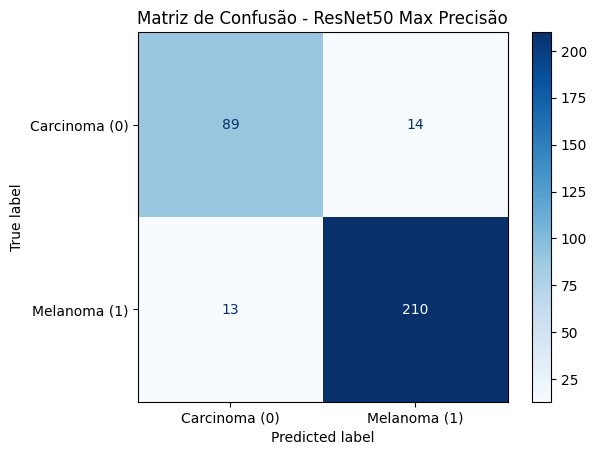

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

def prepare_filtered_data(split_name):
    dataset = DermaMNIST(split=split_name, download=True)
    imgs = dataset.imgs
    labels = dataset.labels.flatten()

    # Filter indices for classes 1 (Carcinoma) and 4 (Melanoma)
    indices = (labels == 1) | (labels == 4)
    filtered_imgs = imgs[indices]
    filtered_labels = labels[indices]

    # Map labels: 1 -> 0 (Carcinoma), 4 -> 1 (Melanoma)
    mapped_labels = np.where(filtered_labels == 1, 0, 1)

    counts = {
        0: int(np.sum(mapped_labels == 0)),
        1: int(np.sum(mapped_labels == 1))
    }

    print(f"Split: {split_name.capitalize()} | Carcinoma (0): {counts[0]} | Melanoma (1): {counts[1]}")
    return filtered_imgs, mapped_labels, counts

# 1. Loading and Balancing Data

print("Loading and filtering data from original DermaMNIST...")
train_imgs_full, train_labels_full, train_counts = prepare_filtered_data('train')
val_imgs_full, val_labels_full, val_counts = prepare_filtered_data('val')
test_imgs_full, test_labels_full, test_counts = prepare_filtered_data('test')

total_train_samples = len(train_labels_full)
weight_class_0 = total_train_samples / (2.0 * train_counts[0])
weight_class_1 = total_train_samples / (2.0 * train_counts[1])

class_weights_tensor: torch.Tensor = torch.tensor([weight_class_0, weight_class_1], dtype=torch.float32)
print(f"Calculated class weights for Loss Function: {class_weights_tensor.tolist()}")

# 2. Custom Dataset & Aggressive Transforms

class DermaDataset(Dataset):
    def __init__(self, imgs, labels, transform):
        self.imgs = imgs
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = Image.fromarray(self.imgs[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

# Resizing to 224x224 and applying robust Data Augmentation
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Critical for ResNet50
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Critical for ResNet50
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Preparing Dataloaders...")
# Reduced batch_size to 16 to avoid OutOfMemory errors since images are now 224x224
train_dataset = DermaDataset(train_imgs_full, train_labels_full, transform=train_transforms)
val_dataset = DermaDataset(val_imgs_full, val_labels_full, transform=eval_transforms)
test_dataset = DermaDataset(test_imgs_full, test_labels_full, transform=eval_transforms)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

# 3. PyTorch Lightning Module definition

class OptimizedDermaClassifier(pl.LightningModule):
    def __init__(self, learning_rate, class_weights = None) -> None:
        super().__init__()
        self.save_hyperparameters()
        
        # Load deeper pre-trained ResNet50
        self.model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        num_ftrs = self.model.fc.in_features
        
        # Adding Dropout for regularization
        self.model.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(num_ftrs, 2)
        )
        
        self.loss_fn = nn.CrossEntropyLoss(weight=class_weights)
        
        self.train_acc = Accuracy(task="multiclass", num_classes=2)
        self.val_acc = Accuracy(task="multiclass", num_classes=2)
        self.test_acc = Accuracy(task="multiclass", num_classes=2)
        self.test_prec = Precision(task="multiclass", num_classes=2)
        self.test_rec = Recall(task="multiclass", num_classes=2)
        self.test_f1 = F1Score(task="multiclass", num_classes=2)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = torch.argmax(logits, dim=1)
        
        self.train_acc(preds, y)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.train_acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = torch.argmax(logits, dim=1)
        
        self.val_acc(preds, y)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.val_acc, prog_bar=True)

    def test_step(self, batch, batch_idx) -> None:
        x, y = batch
        logits = self(x)
        preds = torch.argmax(logits, dim=1)
        
        self.test_acc(preds, y)
        self.test_prec(preds, y)
        self.test_rec(preds, y)
        self.test_f1(preds, y)
        
        self.log('test_acc', self.test_acc)
        self.log('test_precision', self.test_prec)
        self.log('test_recall', self.test_rec)
        self.log('test_f1', self.test_f1)

    def configure_optimizers(self):
        # Increased weight decay for better regularization
        optimizer = AdamW(self.parameters(), lr=self.hparams.learning_rate, weight_decay=1e-3)
        
        # Reduce LR by half if validation accuracy plateaus for 3 epochs
        scheduler = ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-6
        )
        
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_acc"
            }
        }

# 4. Training and Evaluation

print("Initializing Model and Trainer...")
model = OptimizedDermaClassifier(learning_rate=1e-4, class_weights=class_weights_tensor)

checkpoint_callback = ModelCheckpoint(
    monitor='val_acc',
    dirpath='derma_logs_max_acc/',
    filename='resnet50-optimized-{epoch:02d}-{val_acc:.3f}',
    mode='max'
)

# Early stopping to halt training if val_acc stops improving for 8 epochs
early_stop_callback = EarlyStopping(
    monitor='val_acc',
    patience=8,
    mode='max',
    verbose=True
)

trainer = pl.Trainer(
    max_epochs=50,  # Increased max epochs
    callbacks=[checkpoint_callback, early_stop_callback],
    log_every_n_steps=5
)

print("Starting Training...")
trainer.fit(model, train_dataloader, val_dataloader)

print("Running Test Evaluation...")
best_model_path = checkpoint_callback.best_model_path
best_model = OptimizedDermaClassifier.load_from_checkpoint(
    best_model_path, class_weights=class_weights_tensor
)

trainer.test(best_model, test_dataloader)

# Generate Confusion Matrix
best_model.eval()
best_model.to('cuda' if torch.cuda.is_available() else 'cpu')

all_preds = []
all_labels = []

print("Generating Confusion Matrix...")
with torch.no_grad():
    for imgs, labels in test_dataloader:
        imgs = imgs.to(best_model.device)
        logits = best_model(imgs)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Carcinoma (0)', 'Melanoma (1)'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - ResNet50 Max Precisão")
plt.show()